# 정면이미지

In [1]:
!pip install cmake
!pip install opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [2]:
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
import math # 수학 관련 함수들을 사용하기 위해 불러오는(import) 코드, 얼굴 기울어진 각도 계산할 때

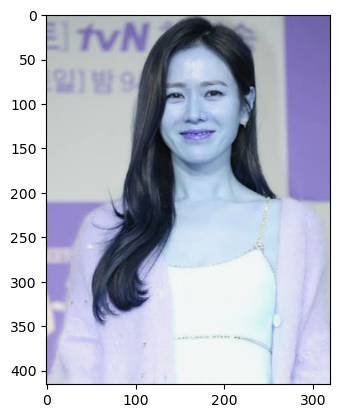

In [3]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/1.png') # 이미지가 있는 경로
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러오기
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려줌. (실제 출력은 하지 않는다)
plt.show() # 이미지를 출력. (실제 출력)

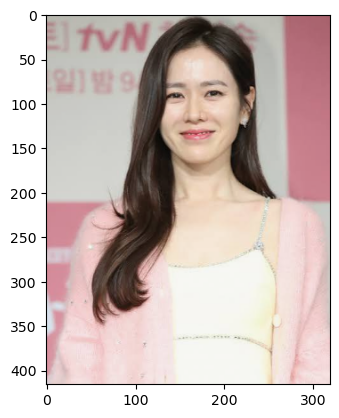

In [4]:
# plt.imshow 이전에 RGB 이미지로 바꿔주기. -> 라이브러리 간의 '색상 해석 방식'이 서로 다르다.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 함.)
plt.show() # 이미지 실제 출력

In [5]:
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
# 얼굴을 찾기 위한 '탐지기(얼굴 감지 모델)'를 시스템에 불러와 준비(선언)하는 역할만

In [6]:
# dlib은 rgb 이미지를 입력으로 받기 때문에 cvtColor() 를 이용해서 opencv 의 bgr 이미지를 rgb로 변환
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# detector_hog를 이용해서 얼굴의 bounding box를 추출
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
# 준비된 탐지기(detector_hog)에게 색상을 맞춘 사진(img_rgb)을 보여주며 실제로 얼굴을 찾으라고 명령하는 코드
# detector_hog의 두 번째 파라미터는 이미지 피라미드의 수. 이미지를 1번 확대(upsampling)해서 꼼꼼히 찾으라는 뜻
# 탐지기가 얼굴을 찾아내면, 그 얼굴이 있는 위치(네모 박스 좌표들)를 dlib_rects라는 변수에 저장

Dlib 라이브러리의 HOG 기반 검출기(주로 dlib.get_frontal_face_detector())를 실행할 때 입력하는  
두 번째 파라미터는 upsample_num_times (이미지 업샘플링 횟수)  

__파라미터의 역할__  
이 값은 탐색을 시작하기 전에 원본 이미지를 몇 번 확대할 것인지를 결정합니다.  
- HOG 얼굴 검출기는 기본적으로 일정 크기(약 80x80 픽셀) 이상의 얼굴을 찾도록 훈련되어 있습니다.  
- 사진 속 사람의 얼굴이 기준 크기보다 작거나 멀리 떨어져 있다면 검출기가 얼굴을 놓치게 됩니다.  
- 이때 두 번째 파라미터 값을 늘려 이미지를 업샘플링(확대)하면, 작은 얼굴도 검출 가능한 크기로 커지기 때문에 인식률이 올라갑니다.

__값에 따른 차이와 트레이드오프__  
0: 원본 이미지 크기 그대로 탐색합니다. 연산 속도가 가장 빠르지만, 작은 얼굴은 탐지하지 못할 수 있습니다.  
1: 이미지를 1번 확대하여 탐색합니다. 가장 보편적으로 사용되는 값입니다.  
2 이상: 이미지를 2번 이상 확대합니다. 사진 속 아주 작은 얼굴도 찾을 수 있게 되지만,  
 이미지 크기가 커지는 만큼 연산 시간과 메모리 사용량이 기하급수적으로 증가하여 처리 속도가 매우 느려집니다.  

💡 추천안  
- 속도가 최우선이거나 실시간 영상(웹캠 등)을 처리할 때: 0  
- 일반적인 사진 분석 시 인식률과 속도의 균형을 원할 때: 1 (권장)  
만약 파라미터 값을 2 이상으로 높여야 할 만큼 대상이 너무 작다면, HOG 방식의 업샘플링을 늘리기보다는 딥러닝 기반의 CNN 얼굴 검출기(dlib.cnn_face_detection_model_v1)를 사용하는 것을 추천

➰ upsampling이란,
간단하게 데이터의 크기를 키우는 것
일반적으로 CNN의 레이어를 통과하면서 이미지의 크기를 줄이는 것을 down sampling이라고 하는데,
down sampling의 반대 개념이 upsampling인 셈

rectangles[[(126, 66) (215, 156)]]


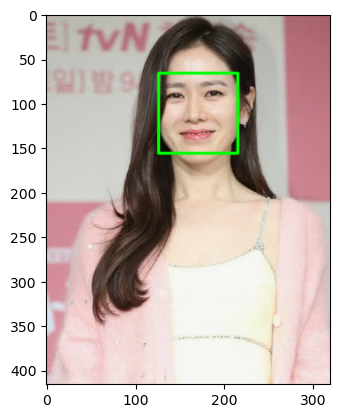

In [7]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: 
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

__detector_hog를 통해 찾아낸 얼굴의 위치 정보를 바탕으로,  
사진 위에 직접 '초록색 네모 박스(바운딩 박스)'를 그리고 화면에 결과물을 보여주는 전체 과정__  

- dlib이 찾아낸 얼굴 영역들의 정보(좌표 객체)를 텍스트로 먼저 출력(l, t, r, b)
- for 반복문:  
사진 안에 얼굴이 여러 명일 수 있으므로, 찾은 모든 얼굴(dlib_rects)을 하나씩 꺼내어(dlib_rect) 반복 작업을 수행  
- l, t, r, b에 저장한 네 개의 점이 있으면 직사각형을 그릴 수 있다.

__cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)__  
- OpenCV의 rectangle 함수를 사용하여 이미지 위에 사각형을 직접 그립니다.  
- img_show: 그림을 그릴 대상 이미지(도화지)입니다.  
- (l, t)와 (r, b): 직사각형의 시작점(왼쪽 위)과 종료점(오른쪽 아래) 좌표입니다.  
- (0, 255, 0): 선의 색상. OpenCV는 BGR 순서를 사용하므로, 파랑(0), 초록(255), 빨강(0)이 되어 초록색 선이 그려진다.
- 2: 선의 두께  
- lineType=cv2.LINE_AA: 선을 그릴 때 계단 현상(픽셀 깨짐)을 방지하여 선을 부드럽게(Anti-Aliasing) 그려주는 옵션  

__img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)__
cvtColor: 박스까지 다 그린 img_show는 현재 OpenCV 기준인 BGR 상태.  
이를 파이썬의 시각화 도구인 matplotlib(plt)가 제대로된 색으로 보여줄 수 있도록 RGB 상태로 다시 변환.  

최종적으로 초록색 박스가 쳐진 얼굴 사진을 주피터 노트북 화면에 출력
plt.imshow() : 지정한 이미지 데이터를 화면에 띄울 수 있도록 컴퓨터 내부의 메모리(가상의 도화지)에 그려 넣는(준비하는) 역할  
plt.show(): 앞서 plt.imshow() 등을 통해 준비해둔 모든 작업물을 실제 모니터 화면에 나타내는 역할

dlib detector 는 dlib.rectangles 타입의 객체를 반환  
dlib.rectangles 는 dlib.rectangle 객체의 배열 형태로 이루어져 있음  
dlib.rectangle객체는 left(), top(), right(), bottom(), height(), width() 등의 멤버 함수를 포함
https://dlib.net/python/index.html#dlib.rectangles

__실무에서 가장 많이 쓰는 코드 패턴__  
- 얼굴 검출기가 반환한 dlib.rectangles에서 개별 사각형(dlib.rectangle)을 꺼내어 사용하는 기본 형태
- OpenCV 함수들은 보통 (x, y, w, h) 형태를 요구하기 때문에, 이 변환식을 헬퍼 함수로 만들어 두면 편리
- 특정 객체를 추적(Tracking)하거나 포커스를 맞출 때 center() 메서드가 유용  


💡 Tips
-  Dlib은 사각형을 (left, top, right, bottom)이라는 두 점의 절대 좌표로 인식하지만,  
 OpenCV는 (x, y, width, height) 방식의 시작점과 크기로 인식합니다.  
 둘을 혼용할 때 이 차이를 잊으면 엉뚱한 위치에 박스가 그려지게 됩니다.  

- 화면 가장자리에 얼굴이 반쯤 걸쳐 있을 경우, 검출된 rect.left()나 rect.top()이 음수(-) 값을 가지거나,  
 right/bottom 값이 실제 이미지 크기를 벗어날 수 있습니다. 나중에 이 좌표로 이미지를 자를(Crop) 일이 있다면,
 반드시 0 이상, 이미지 최대 크기 이하로 좌표를 제한(Clipping) 하는 예외 처리를 해야 오류를 막을 수 있다.

- 너무 작거나 오탐지된 영역을 걸러낼 때 rect.area()를 사용해 특정 픽셀 수 이하의 사각형은 무시하는 조건을 쉽게 추가할 수 있다.

__이목구비의 위치를 추론하는 것을 face landmark localization 기술__  
face landmark는 detection 의 결과물인 bounding box 로 잘라낸(crop) 얼굴 이미지를 이용  

Face landmark와 같이 객체 내부의 점을 찾는 기술을 __object keypoint estimation__  
1. top-down : bounding box를 찾고 box 내부의 keypoint를 예측  
2. bottom-up : 이미지 전체의 keypoint를 먼저 찾고 point 관계를 이용해 군집화 해서 box 생성  

In [8]:
# !wget -c (끊기면 이어서 받음)
!wget -c http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models
# 폴더를 이동하지 않고, 파일이 있는 전체 경로(절대 경로)를 직접 지정해서 압축을 풀기
!bzip2 -d work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2

--2026-06-22 08:11:31--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 08:11:31--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

mv: cannot move 'shape_predictor_68_face_landmarks.dat.bz2' to 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models': No such file or directory
bzip2: Can't open input file work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2: No such file or directory.


In [9]:
# 저장한 landmark 모델의 주소를 model_path 변수에 저장
model_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat') 
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # shape_predictor = 얼굴 사진을 넣으면 눈, 코, 입 위치를 찾아주는 AI 모델 (얼굴의 특징점 68개를 찾음)
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄

In [10]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


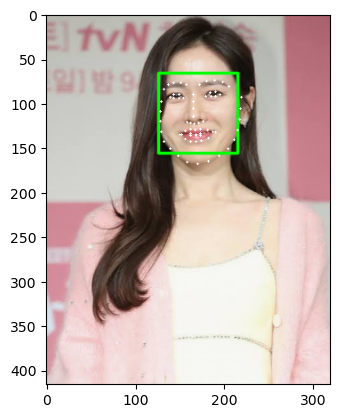

In [11]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 1, (255, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

세 번째 위치한 숫자 2는 원의 반지름(크기) - 크게 숫자 키우기 작게는 반대  

🔴 빨간색 점: 파랑(0), 초록(0), 빨강(255)  
🟡 노란색 점 : 파랑(0), 초록(255), 빨강(255)   
🟢 초록색 점: 파랑(0), 초록(255), 빨강(0)  
🔵 파란색 점: 파랑(255), 초록(0), 빨강(0)  
⚪ 하얀색 점: 모든 빛을 최대로 섞음  
⚫ 검은색 점: 모든 빛을 끔  

- 맨 끝에 있는 -1은 '원의 내부를 색상으로 꽉 채우겠다(Fill)'는 뜻입니다.   
만약 이 값을 1이나 2 같은 양수로 바꾸면, 속이 빈 동그라미(선 두께가 1 또는 2인 원)가 그려집니다.

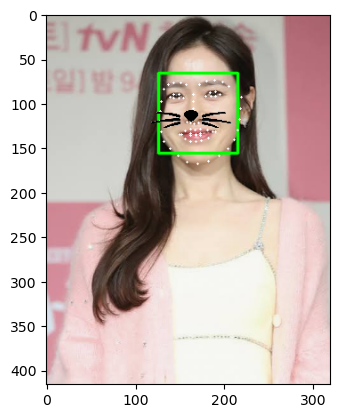

In [12]:
# 1. 수염 스티커 경로 설정 및 불러오기
sticker_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path)

# 2. 찾은 얼굴들에 각각 수염 붙이기
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): 
    # [위치] 코끝(30번)을 중심 좌표로 설정
    x = landmark[31][0] 
    y = landmark[31][1]

    # [크기] 수염 크기를 얼굴 너비에 맞춤
    w = h = dlib_rect.width() 
    
    # 스티커 크기 조정
    img_sticker_resized = cv2.resize(img_sticker, (w,h))

    # [시작점] 수염의 정중앙이 코끝(x, y)에 오도록 좌측 상단 좌표 계산
    # + / - 추가해 위치 조절
    refined_x = (x - w // 2) + 5
    refined_y = (y - h // 2) - 3

    # --- [안전장치] 스티커가 사진 밖으로 나가는 경우 잘라내기 ---
    # 사진 범위를 벗어나지 않도록 시작점과 끝점을 계산합니다.
    start_x = max(0, refined_x)
    start_y = max(0, refined_y)
    end_x = min(img_show.shape[1], refined_x + w)
    end_y = min(img_show.shape[0], refined_y + h)

    # 스티커 이미지에서 실제 사진에 들어갈 부분만 오려내기
    sticker_crop = img_sticker_resized[
        (start_y - refined_y) : (end_y - refined_y), 
        (start_x - refined_x) : (end_x - refined_x)
    ]

    # 사진에서 스티커가 합성될 영역(도화지) 지정
    sticker_area = img_show[start_y:end_y, start_x:end_x]

    # --- [합성] 배경은 투명하게, 수염만 덮어씌우기 ---
    import numpy as np
    img_show[start_y:end_y, start_x:end_x] = \
        np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)

# 3. 최종 결과물 화면에 띄우기
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

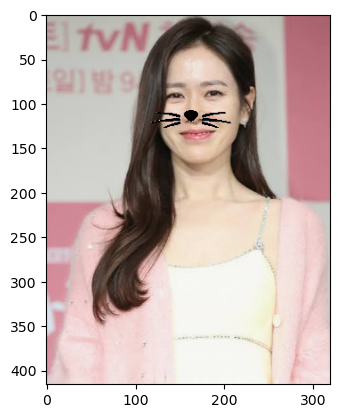

In [13]:
# 12번 셀에서 계산된 정확한 영역(start, end)을 원본 이미지(img_bgr) 도화지로 지정
sticker_area = img_bgr[start_y:end_y, start_x:end_x]

# 이미 크기 조정과 자르기가 완료된 스티커(sticker_crop)를 img_bgr에 합성
# (고양이 수염 배경이 흰색이므로 12번 셀과 동일하게 255를 투명 처리 조건으로 지정)
img_bgr[start_y:end_y, start_x:end_x] = \
    np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)

# 최종 결과물 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# 기울기

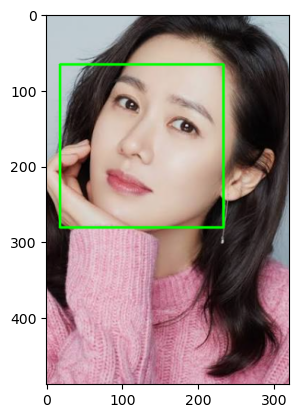

In [14]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/3.png') 
img_bgr = cv2.imread(my_image_path)    
img_show = img_bgr.copy()      

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

detector_hog = dlib.get_frontal_face_detector() 

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 0) 

for dlib_rect in dlib_rects: 
    l = dlib_rect.left() 
    t = dlib_rect.top() 
    r = dlib_rect.right() 
    b = dlib_rect.bottom() 

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) 

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [15]:
!wget -c http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models
!bzip2 -d work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2

--2026-06-22 08:11:35--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 08:11:35--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

mv: cannot move 'shape_predictor_68_face_landmarks.dat.bz2' to 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models': No such file or directory
bzip2: Can't open input file work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2: No such file or directory.


In [16]:
model_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat') 
landmark_predictor = dlib.shape_predictor(model_path)

In [17]:
list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (255, 255, 255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

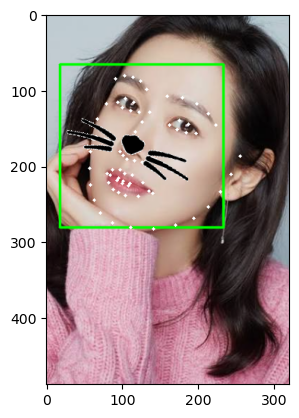

In [18]:
sticker_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path)

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): 
    x = landmark[32][0] 
    y = landmark[32][1] 
    w = h = dlib_rect.width() 

    # 2. 80%로 줄어든 새로운 너비와 높이를 미리 계산합니다.
    w_resized = int(w * 0.8)
    h_resized = int(h * 0.8)
    
    # 줄어든 크기 변수를 적용해 스티커를 리사이즈
    img_sticker_resized = cv2.resize(img_sticker, (w_resized, h_resized))

    # 얼굴 각도에 맞춰 스티커 회전하기
    # 양쪽 눈의 좌표 가져오기 (36번: 왼쪽 눈 끝, 45번: 오른쪽 눈 끝)
    left_eye = landmark[36]
    right_eye = landmark[45]

    # 두 눈 사이의 가로(dx) 및 세로(dy) 거리 계산
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    # math.atan2 로 각도(라디안)를 구하고, 우리가 아는 각도(도, degree)로 변환
    angle = math.degrees(math.atan2(dy, dx))
    
    # 스티커의 중심을 기준으로 회전 행렬 만들기
    # cv2.getRotationMatrix2D(회전 중심 좌표, 회전 각도, 확대/축소 비율)
    center_of_sticker = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center_of_sticker, -angle, 1.0)

    # 실제로 스티커 이미지 회전시키기, img_sticker_rotated 로 변경
    # borderValue=(255, 255, 255)는 회전하면서 생기는 빈 공간을 흰색(배경색)으로 채워줍니다.
    img_sticker_rotated = cv2.warpAffine(img_sticker_resized, rotation_matrix, (w, h), borderValue=(255, 255, 255))
    

    refined_x = x - w_resized // 2
    refined_y = y - h_resized // 2

    start_x = max(0, refined_x)
    start_y = max(0, refined_y)
    end_x = min(img_show.shape[1], refined_x + w_resized)
    end_y = min(img_show.shape[0], refined_y + h_resized)

    # 스티커 자르기 (회전된 이미지 사용)
    sticker_crop = img_sticker_rotated[
        (start_y - refined_y) : (end_y - refined_y), 
        (start_x - refined_x) : (end_x - refined_x)
    ]

    sticker_area = img_show[start_y:end_y, start_x:end_x]

    img_show[start_y:end_y, start_x:end_x] = \
        np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)


plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

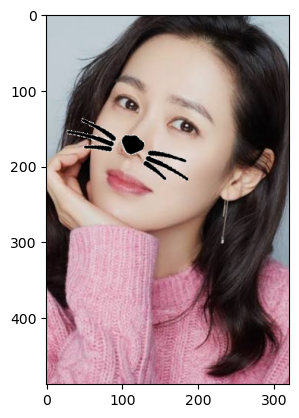

In [19]:
# 영역(start, end)을 원본 이미지(img_bgr) 도화지로 지정
sticker_area = img_bgr[start_y:end_y, start_x:end_x]

# 이미 크기 조정과 자르기가 완료된 스티커(sticker_crop)를 img_bgr에 합성
# (고양이 수염 배경이 흰색이므로 12번 셀과 동일하게 255를 투명 처리 조건으로 지정)
img_bgr[start_y:end_y, start_x:end_x] = \
    np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)

# 최종 결과물 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# 거리

--2026-06-22 08:11:38--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 08:11:39--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

mv: cannot move 'shape_predictor_68_face_landmarks.dat.bz2' to 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models': No such file or directory
bzip2: Can't open input file work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2: No such file or directory.
68


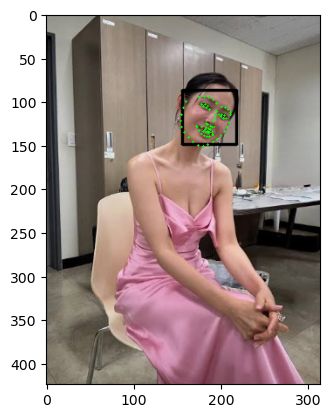

In [20]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/4.png') 
img_bgr = cv2.imread(my_image_path)   
img_show = img_bgr.copy()    

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

detector_hog = dlib.get_frontal_face_detector()

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)
# (img_rgb, 1) 여기서 숫자 1로 설정하면 이미지를 1번 더 확대(upsampling)해서 꼼꼼하게 작은 얼굴까지 찾는다.

for dlib_rect in dlib_rects: 
    l = dlib_rect.left() 
    t = dlib_rect.top() 
    r = dlib_rect.right() 
    b = dlib_rect.bottom() 

    cv2.rectangle(img_show, (l,t), (r,b), (0,0,0), 2, lineType=cv2.LINE_AA)

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

!wget -c http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models
!bzip2 -d work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2

model_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat') 
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

print(len(list_landmarks[0])) 

for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 1, (0, 255, 0), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

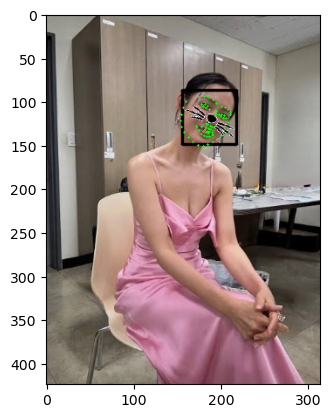

In [21]:
sticker_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path)

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): 
    x = landmark[31][0] 
    y = landmark[31][1]
    w = h = dlib_rect.width() 
    
    img_sticker_resized = cv2.resize(img_sticker, (w,h))

    left_eye = landmark[36]
    right_eye = landmark[45]

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    angle = math.degrees(math.atan2(dy, dx))
    
    center_of_sticker = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center_of_sticker, -angle, 1.0)

    img_sticker_rotated = cv2.warpAffine(img_sticker_resized, rotation_matrix, (w, h), borderValue=(255, 255, 255))

    refined_x = (x - w // 2) + 5
    refined_y = (y - h // 2) - 3

    start_x = max(0, refined_x)
    start_y = max(0, refined_y)
    end_x = min(img_show.shape[1], refined_x + w)
    end_y = min(img_show.shape[0], refined_y + h)

    sticker_crop = img_sticker_rotated[
        (start_y - refined_y) : (end_y - refined_y), 
        (start_x - refined_x) : (end_x - refined_x)
    ]

    sticker_area = img_show[start_y:end_y, start_x:end_x]

    import numpy as np
    img_show[start_y:end_y, start_x:end_x] = \
        np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

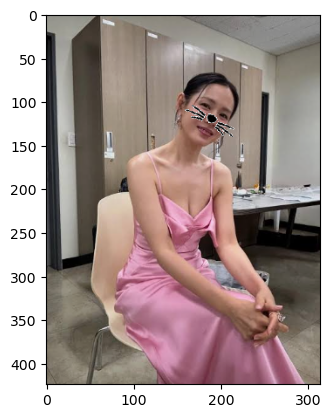

In [22]:
sticker_area = img_bgr[start_y:end_y, start_x:end_x]

img_bgr[start_y:end_y, start_x:end_x] = \
    np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

# 이미지 밝기

--2026-06-22 08:11:42--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 08:11:43--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

mv: cannot move 'shape_predictor_68_face_landmarks.dat.bz2' to 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models': No such file or directory
bzip2: Can't open input file work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2: No such file or directory.
68


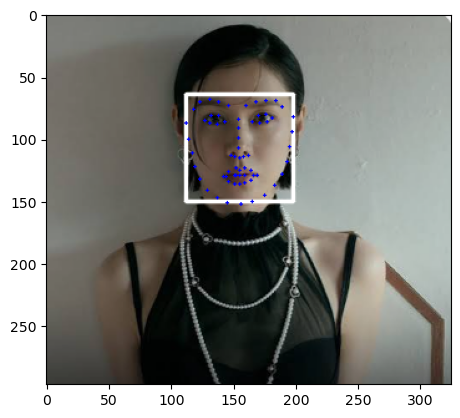

In [23]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/2.png') 
img_bgr = cv2.imread(my_image_path)   
img_show = img_bgr.copy()    

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

detector_hog = dlib.get_frontal_face_detector()

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 0)


for dlib_rect in dlib_rects: 
    l = dlib_rect.left() 
    t = dlib_rect.top() 
    r = dlib_rect.right() 
    b = dlib_rect.bottom() 

    cv2.rectangle(img_show, (l,t), (r,b), (255,255,255), 2, lineType=cv2.LINE_AA)

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

!wget -c http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models
!bzip2 -d work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2

model_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/models/shape_predictor_68_face_landmarks.dat') 
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

print(len(list_landmarks[0])) 

for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 1, (255, 0, 0), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

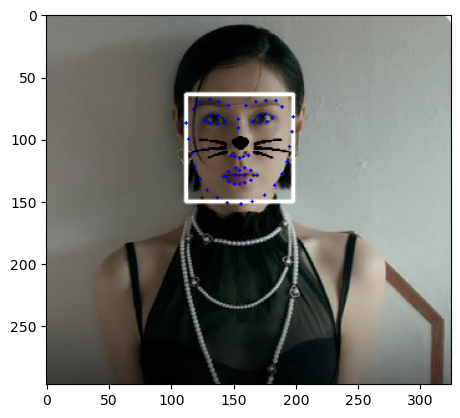

In [24]:
# 1. 수염 스티커 경로 설정 및 불러오기
sticker_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV01/camera_sticker/images/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path)

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): 
    x = landmark[30][0] 
    y = landmark[30][1] 
    w = h = dlib_rect.width() 

    # 줄어든 새로운 너비와 높이를 미리 계산합니다.
    w_resized = int(w * 0.9)
    h_resized = int(h * 0.9)
    
    # 줄어든 크기 변수를 적용해 스티커를 리사이즈
    img_sticker_resized = cv2.resize(img_sticker, (w_resized, h_resized))

    # 좌표 계산 및 도화지(sticker_area) 영역 지정
    refined_x = (x - w_resized // 2) + 2
    refined_y = y - h_resized // 2

    # 사진 밖으로 나가는 것 방지 (안전장치)
    start_x = max(0, refined_x)
    start_y = max(0, refined_y)
    end_x = min(img_show.shape[1], refined_x + w_resized)
    end_y = min(img_show.shape[0], refined_y + h_resized)

    # 스티커와 도화지 영역 잘라내기
    sticker_crop = img_sticker_resized[(start_y - refined_y):(end_y - refined_y), 
                                       (start_x - refined_x):(end_x - refined_x)]
    sticker_area = img_show[start_y:end_y, start_x:end_x]

    # ==============================================================
    # 배경 얼굴의 음영(그림자) 스티커에 적용하기
    # 배경 얼굴을 흑백으로 변환하여 밝기 정보(Light Map) 추출
    bg_light_map = cv2.cvtColor(sticker_area, cv2.COLOR_BGR2GRAY)

    # 밝기를 0.0 ~ 1.0 비율로 변환
    light_ratio = (bg_light_map / 255.0) * 0.8 + 0.2

    # 스티커 이미지(sticker_crop)에 배경의 밝기 비율을 곱해서 그림자 씌우기
    sticker_shadowed = np.zeros_like(sticker_crop, dtype=np.float32)
    for c in range(3): # B, G, R 3가지 색상 채널 모두에 밝기 비율 적용
        sticker_shadowed[:, :, c] = sticker_crop[:, :, c] * light_ratio

    # 다시 이미지 형태로 변환
    sticker_shadowed = sticker_shadowed.astype(np.uint8)
    # ==============================================================

    # 주의: 마지막에 덮어씌울 이미지를 sticker_crop 에서 그림자가 적용된 sticker_shadowed 로 변경!
    import numpy as np
    img_show[start_y:end_y, start_x:end_x] = \
        np.where(sticker_crop==255, sticker_area, sticker_shadowed).astype(np.uint8)

# 최종 결과물 화면에 띄우기
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

light_ratio = (기본 밝기 비율) * A + B  
- B (더하는 값) = 최소 밝기 방어선: 배경이 아무리 캄캄한 어둠(0.0)이어도, 스티커는 최소한 이 숫자만큼의 밝기는 유지  
- A (곱하는 값) = 그림자의 대비: 밝은 곳과 어두운 곳의 차이를 얼마나 뚜렷하게 줄 것인지 결정  
보통 자연스러운 결과를 위해 A + B = 1.0이 되도록 숫자를 맞춘다.  

1. * 1.0 + 0.0 : 배경이 0(완전 검은색)이면 수염 스티커도 0(완전 검은색)
2. * 0.8 + 0.2 : 가장 어두운 곳에서도 스티커의 원래 밝기를 20%는 남겨둔다.
3. * 0.7 + 0.3 : 최소 30%의 밝기를 보장. 적당한 그림자가 지면서도 스티커의 형태를 잃지 않는 가장 무난하고 표준적인 수치
4. * 0.3 + 0.7 : 그림자를 아주 연하게 주고 싶을 때, 

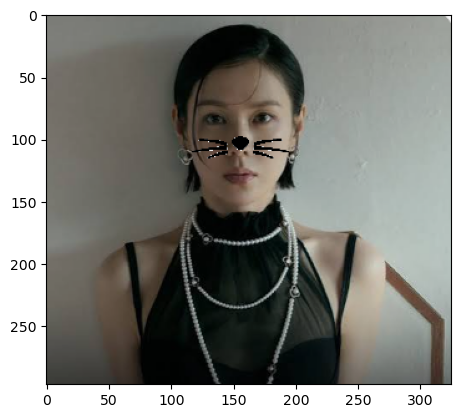

In [25]:
sticker_area = img_bgr[start_y:end_y, start_x:end_x]

img_bgr[start_y:end_y, start_x:end_x] = \
    np.where(sticker_crop==255, sticker_area, sticker_crop).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

shape_predictor은 얼굴사진을 넣으면 눈, 코, 입 위치를 68개의 점을 찍어 찾아주는 학습된 AI모델.  
기본적인 코드는 동일하고 사진에 따라 스티커 기울기 추가하기, 사이즈 조절하기, 밝기 추가함.  

노드 학습에서 사용한 코드에서 추가적인 부분만 변경하면서 시도해서 큰 어려움은 없었는데 노드가 없었으면 수행하는데 어려움을 겪었을거같다.
추가 코드를 적용하면서 기울기는 math라이브러리를 불러오니 쉽게 적용할 수 있었는데, 쉽게 생각했던 스티커 사이즈 변경은 사이즈를 줄이니 스티커 위치가 아예 변경되버려 추가적인 코드를 넣어서 수정이 필요했다.
촬영거리 변수는 기본 코드에서 설정이 잘되어 있어서 인식이 잘되었고, 사진밝기 조절 코드를 넣어봤는데 차이가 있는지 잘 모르겠다. 